In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin

In [75]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

def remove_outliers(df):
    df = df.copy()
    df = df.drop_duplicates()
    df = df[df["density"] <= 1.01]
    df = df[df["chlorides"] < 0.3]
    df = df[df["fixed acidity"] < 12]
    df = df[df["free sulfur dioxide"] < 100]
    df = df[df["citric acid"] < 0.75]
    df = df[df["total sulfur dioxide"] < 300]
    df = df[df["sulphates"] < 1.25]
    return df

def feature_engineering(df):
    df = df.copy()
    df["type"] = df["type"].map({"red": 0, "white": 1})
    df["quality"] = pd.cut(
        df["quality"],
        bins=[0, 4, 6, 10],
        labels=["Low", "Intermediate", "High"]
    )
    df["quality"] = df["quality"].map({"Low": 0, "Intermediate": 1, "High": 2})
    return df

def split(dataframe, random_state=42, train_size=0.8):
    dataframe = feature_engineering(dataframe)
    X = dataframe.drop(columns=["quality"])
    y = dataframe["quality"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=(1 - train_size),
        stratify=y,
        random_state=random_state
    )

    train_df = X_train.assign(quality=y_train)
    train_df = remove_outliers(train_df)
    X_train = train_df.drop(columns=["quality"])
    y_train = train_df["quality"]

    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)
    return X_train, X_test, y_train, y_test, scaler

def apply_smote(
    X_train,
    y_train,
    sampling_strategy="auto",
    k_neighbors=5,
    random_state=42
):
    """
    Aplica SMOTE no conjunto de treino para balanceamento de classes.

    Parameters
    ----------
    X_train : array-like or pd.DataFrame
        Features do conjunto de treino.
    y_train : array-like or pd.Series
        Labels do conjunto de treino.
    sampling_strategy : str, dict or float, default="auto"
        Estratégia de balanceamento.
        - "auto": balanceia todas as classes minoritárias até a majoritária
        - dict: define número desejado por classe, ex: {0: 200, 2: 300}
    k_neighbors : int, default=5
        Número de vizinhos usados na interpolação.
        Use valores menores (ex: 3) para classes muito pequenas.
    random_state : int, default=42
        Reprodutibilidade.

    Returns
    -------
    X_resampled : array-like
        Features após SMOTE.
    y_resampled : array-like
        Labels após SMOTE.
    """

    smote = SMOTE(
        sampling_strategy=sampling_strategy,
        k_neighbors=k_neighbors,
        random_state=random_state
    )

    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    return X_resampled, y_resampled

In [76]:
df = pd.read_csv("../dataset/wine_quality_red_white.csv")
X_train, X_test, y_train, y_test, scaler = split(df)
X_train, y_train = apply_smote(X_train, y_train)

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import randint, uniform


def train_XGBoost(X_train, y_train):
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    param_dist = {
        'n_estimators': randint(200, 1000),
        'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2],
        'max_depth': randint(3, 15),
        'min_child_weight': randint(1, 15),
        'subsample': uniform(0.5, 0.5),
        'colsample_bytree': uniform(0.5, 0.5),
        'gamma': uniform(0, 0.5),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0.5, 2),
    }

    xgb_clf = XGBClassifier(
        random_state=42,
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss'
    )

    random_search = RandomizedSearchCV(
        estimator=xgb_clf,
        param_distributions=param_dist,
        n_iter=200,
        cv=5,
        scoring='f1_weighted',
        refit=True,
        return_train_score=True,
        random_state=42,
        n_jobs=-1
    )

    print("Starting hyperparameter search...")
    random_search.fit(X_train, y_train, sample_weight=sample_weights)
    print("Finished!")

    print(f"Best CV F1: {random_search.best_score_:.4f}")
    print(f"Best params: {random_search.best_params_}")

    return random_search.best_estimator_, random_search.best_params_



In [77]:
estimator, params = train_XGBoost(X_train, y_train)

Starting hyperparameter search...
Finished!
Best CV F1: 0.9172
Best params: {'colsample_bytree': np.float64(0.7537338668804181), 'gamma': np.float64(0.00319293585841679), 'learning_rate': 0.2, 'max_depth': 13, 'min_child_weight': 1, 'n_estimators': 432, 'reg_alpha': np.float64(0.6318135270166684), 'reg_lambda': np.float64(1.0196071621283196), 'subsample': np.float64(0.8170028515498057)}


In [78]:
y_pred = estimator.predict(X_test)

from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Test F1: {f1:.4f}")

Test F1: 0.8358


# Random Forest Classification

In [12]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint


def train_RandomForest(X_train, y_train):
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    param_dist = {
        'n_estimators': randint(200, 1000),
        'max_depth': randint(3, 20),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 20),
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    }

    rf_clf = RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )

    random_search = RandomizedSearchCV(
        estimator=rf_clf,
        param_distributions=param_dist,
        n_iter=200,
        cv=5,
        scoring='f1_weighted',
        refit=True,
        return_train_score=True,
        random_state=42,
        n_jobs=-1
    )

    print("Starting Random Forest hyperparameter search...")
    random_search.fit(X_train, y_train, sample_weight=sample_weights)
    print("Finished!")

    print(f"Best CV F1: {random_search.best_score_:.4f}")
    print(f"Best params: {random_search.best_params_}")

    return random_search.best_estimator_, random_search.best_params_

In [79]:
rf_estimator, rf_params = train_RandomForest(X_train, y_train)

Starting Random Forest hyperparameter search...


/media/leonardo-stabile/HD1TB/PROJETOS/Wine Quality/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/media/leonardo-stabile/HD1TB/PROJETOS/Wine Quality/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/media/leonardo-stabile/HD1TB/PROJETOS/Wine Quality/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/media/leonardo-s

Finished!
Best CV F1: 0.9119
Best params: {'bootstrap': False, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 345}


In [82]:
y_pred = rf_estimator.predict(X_test)

from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Test F1: {f1:.4f}")

Test F1: 0.8241


In [ ]:
import joblib

def save_artifacts(path, model, scaler=None):
    artifacts = {
        "model": model,
        "scaler": scaler,
    }
    joblib.dump(artifacts, path)

In [83]:
save_artifacts(
    "dummy_models/model_XGBoost.joblib",
    model=estimator,
    scaler=scaler
)

save_artifacts(
    "dummy_models/model_RF.joblib",
    model=rf_estimator,
    scaler=scaler
)

### Calibration

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    estimator,
    method='isotonic',
    cv=5
)

calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",524
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'

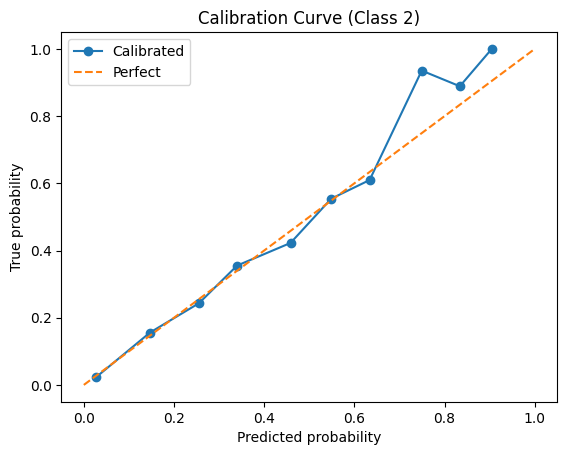

In [48]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# escolha da classe (ex: classe 2)
y_proba = calibrated_model.predict_proba(X_test)[:, 2]

# transformar em problema binário (one-vs-rest)
y_true = (y_test == 2).astype(int)

prob_true, prob_pred = calibration_curve(
    y_true,
    y_proba,
    n_bins=10
)

plt.plot(prob_pred, prob_true, marker='o', label='Calibrated')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect')

plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve (Class 2)")
plt.legend()
plt.show()

In [50]:
import numpy as np
from sklearn.metrics import f1_score

y_proba = calibrated_model.predict_proba(X_test)
y_true = y_test.values  # se for pandas

In [51]:
y_pred_default = np.argmax(y_proba, axis=1)
f1_default = f1_score(y_true, y_pred_default, average='weighted')

print(f"Default F1: {f1_default:.4f}")

Default F1: 0.7767


In [56]:
thresholds = np.linspace(0.1, 0.9, 100)
f1_scores = []

In [57]:
import numpy as np

def predict_with_thresholds(y_proba, thresholds):
    # y_proba: (n_samples, n_classes)
    # thresholds: array shape (n_classes,)
    scores = y_proba / thresholds
    return np.argmax(scores, axis=1)

In [58]:
from sklearn.metrics import f1_score

def optimize_thresholds(y_proba, y_true):
    grid = np.linspace(0.2, 0.8, 7)  # coarse grid

    best_f1 = -1
    best_t = None

    for t0 in grid:
        for t1 in grid:
            for t2 in grid:
                thresholds = np.array([t0, t1, t2])
                y_pred = predict_with_thresholds(y_proba, thresholds)

                f1 = f1_score(y_true, y_pred, average='weighted')

                if f1 > best_f1:
                    best_f1 = f1
                    best_t = thresholds

    return best_t, best_f1

In [59]:
y_proba = calibrated_model.predict_proba(X_test)
y_true = y_test.values

best_thresholds, best_f1 = optimize_thresholds(y_proba, y_true)

print("Best thresholds:", best_thresholds)
print("Best F1:", best_f1)

Best thresholds: [0.2 0.6 0.4]
Best F1: 0.7942414774114774


In [60]:
y_pred_opt = predict_with_thresholds(y_proba, best_thresholds)

<Figure size 1200x500 with 0 Axes>

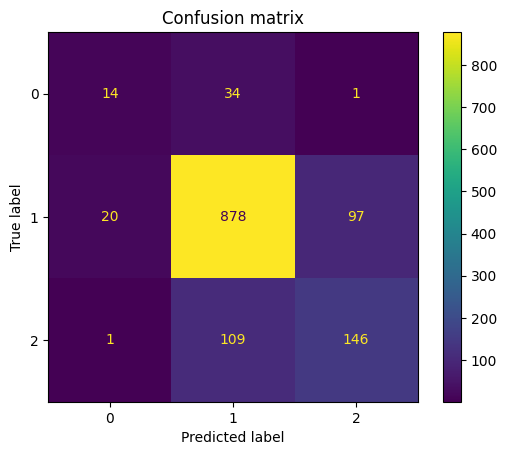

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred_opt
)
plt.title("Confusion matrix")

plt.show()

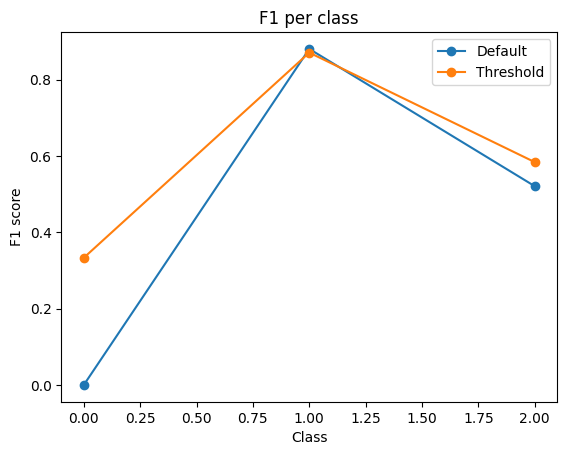

In [70]:
from sklearn.metrics import f1_score

f1_default = f1_score(y_true, y_pred_default, average=None)
f1_opt = f1_score(y_true, y_pred_opt, average=None)

classes = range(len(f1_default))

plt.plot(classes, f1_default, marker='o', label='Default')
plt.plot(classes, f1_opt, marker='o', label='Threshold')

plt.xlabel("Class")
plt.ylabel("F1 score")
plt.title("F1 per class")
plt.legend()
plt.show()

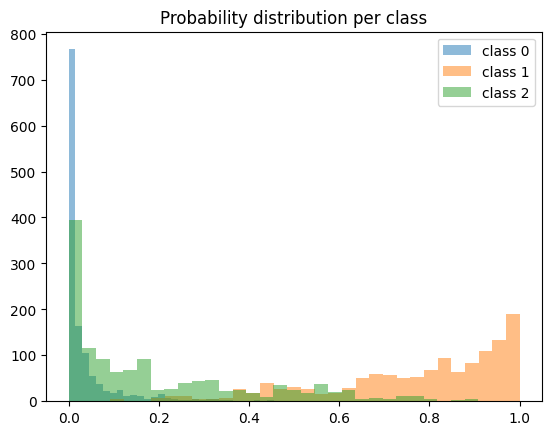

In [71]:
import matplotlib.pyplot as plt

for i in range(3):
    plt.hist(y_proba[:, i], bins=30, alpha=0.5, label=f'class {i}')

plt.title("Probability distribution per class")
plt.legend()
plt.show()

In [73]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_opt))

              precision    recall  f1-score   support

           0       0.40      0.29      0.33        49
           1       0.86      0.88      0.87       995
           2       0.60      0.57      0.58       256

    accuracy                           0.80      1300
   macro avg       0.62      0.58      0.60      1300
weighted avg       0.79      0.80      0.79      1300

